In [1]:
import os
from PIL import Image
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms as transforms

labels = pd.read_csv('../cifar-10/trainLabels.csv')
transform = transforms.ToTensor()

class_to_idx = {
    "airplane": 0,
    "automobile": 1,
    "bird": 2,
    "cat": 3,
    "deer": 4,
    "dog": 5,
    "frog": 6,
    "horse": 7,
    "ship": 8,
    "truck": 9
}

torch.manual_seed(42)

In [2]:
class CIFAR10Dataset(Dataset):
    def __init__(self, image_dir, labels):
        self.image_dir = image_dir
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image_id = self.labels.iloc[index]["id"]
        image_label = self.labels.iloc[index]["label"]

        image_path = os.path.join(self.image_dir, f"{image_id}.png")

        image = Image.open(image_path)
        image = transform(image)
        label = class_to_idx[image_label]

        return image, label

In [3]:
generator = torch.Generator().manual_seed(42)

train_dataset = CIFAR10Dataset(
    "../cifar-10/train",
    labels
)

train_size = int(0.8 * len(train_dataset))
val_size = int(0.1 * len(train_dataset))
test_size = int(0.1 * len(train_dataset))

train_dataset, val_dataset, test_dataset = random_split(
    train_dataset,
    [train_size, val_size, test_size],
    generator
)

print(f"Length of train dataset: {len(train_dataset)}")
print(f"Length of validation dataset: {len(val_dataset)}")
print(f"Length of test dataset: {len(test_dataset)}")

Length of train dataset: 40000
Length of validation dataset: 5000
Length of test dataset: 5000


In [4]:
image, label = train_dataset[0]
print("Train Dataset :-")
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

image, label = val_dataset[0]
print("\nValidation Dataset :-")
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

image, label = test_dataset[0]
print("\nTest Dataset :-")
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

Train Dataset :-
Image shape: torch.Size([3, 32, 32])
Label: 6

Validation Dataset :-
Image shape: torch.Size([3, 32, 32])
Label: 7

Test Dataset :-
Image shape: torch.Size([3, 32, 32])
Label: 7


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

images, labels_batch = next(iter(train_loader))
print("Train Dataloader :-")
print(f"Image Shape: {images.shape}")
print(f"Label: {labels_batch.shape}")

images, labels_batch = next(iter(val_loader))
print("\nValidation Dataloader :-")
print(f"Image Shape: {images.shape}")
print(f"Label: {labels_batch.shape}")

images, labels_batch = next(iter(test_loader))
print("\nTest Dataloader :-")
print(f"Image Shape: {images.shape}")
print(f"Label: {labels_batch.shape}")

Train Dataloader :-
Image Shape: torch.Size([32, 3, 32, 32])
Label: torch.Size([32])

Validation Dataloader :-
Image Shape: torch.Size([32, 3, 32, 32])
Label: torch.Size([32])

Test Dataloader :-
Image Shape: torch.Size([32, 3, 32, 32])
Label: torch.Size([32])


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [7]:
class CIFARBaseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            # Layer 1: 3*32*32 -> 32*32*32
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),

            # Layer 2: 32*32*32 -> 64*16*16
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Layer 3: 64*16*16 -> 128*8*8
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.network = nn.Sequential(
            nn.Flatten(),

            # Layer 1: 8192 -> 256
            nn.Linear(
                in_features=128*8*8,
                out_features=256
            ),
            nn.ReLU(),

            # Layer 2: 256 -> 128
            nn.Linear(
                in_features=256,
                out_features=128
            ),
            nn.ReLU(),

            # Layer 3: 128 -> 10
            nn.Linear(
                in_features=128,
                out_features=10
            )
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.network(x)

        return x

model = CIFARBaseline().to(device)
model

CIFARBaseline(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [8]:
from torchmetrics.classification import Accuracy, Precision, Recall

train_acc_metric = Accuracy(task='multiclass', num_classes=10).to(device)
train_prec_metric = Precision(task='multiclass', num_classes=10, average='macro').to(device)
train_rec_metric = Recall(task='multiclass', num_classes=10, average='macro').to(device)

val_acc_metric = Accuracy(task='multiclass', num_classes=10).to(device)
val_prec_metric = Precision(task='multiclass', num_classes=10, average='macro').to(device)
val_rec_metric = Recall(task='multiclass', num_classes=10, average='macro').to(device)

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001
)

epochs = 10
best_val_accuracy = 0

train_loss_graph = []
val_loss_graph = []
train_acc_graph = []
val_acc_graph = []
train_prec_graph = []
val_prec_graph = []
train_rec_graph = []
val_rec_graph = []


for epoch in range(epochs):

    # Training Loop
    model.train()
    train_loss = 0
    train_acc = 0
    train_prec = 0
    train_rec = 0

    for images, label_batch in train_loader:
        images, label_batch = images.to(device), label_batch.to(device)
        output = model(images)
        loss = loss_fn(output, label_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        train_acc_metric.update(output, label_batch)
        train_prec_metric.update(output, label_batch)
        train_rec_metric.update(output, label_batch)


    train_loss = train_loss / len(train_loader)

    train_loss_graph.append(train_loss)
    train_acc = train_acc_metric.compute().item()
    train_prec = train_prec_metric.compute().item()
    train_rec =  train_rec_metric.compute().item()

    train_acc_graph.append(train_acc)
    train_prec_graph.append(train_prec)
    train_rec_graph.append(train_rec)

    train_acc_metric.reset()
    train_prec_metric.reset()
    train_rec_metric.reset()

    # Validation Loop
    model.eval()
    val_loss = 0
    val_acc = 0
    val_prec = 0
    val_rec = 0
    with torch.inference_mode():
        for images, label_batch in val_loader:
            images, label_batch = images.to(device), label_batch.to(device)
            output = model(images)
            loss = loss_fn(output, label_batch)

            val_loss += loss.item()

            val_acc_metric.update(output, label_batch)
            val_prec_metric.update(output, label_batch)
            val_rec_metric.update(output, label_batch)

    val_loss = val_loss / len(val_loader)

    val_loss_graph.append(val_loss)
    val_acc = val_acc_metric.compute().item()
    val_prec = val_prec_metric.compute().item()
    val_rec =  val_rec_metric.compute().item()

    val_acc_graph.append(val_acc)
    val_prec_graph.append(val_prec)
    val_rec_graph.append(val_rec)

    val_acc_metric.reset()
    val_prec_metric.reset()
    val_rec_metric.reset()

    print(f"\nEpoch {epoch + 1}:")
    print(f"Training Loss: {train_loss:.4f} | Training Accuracy: {train_acc * 100:.2f}% | Training Precision: {train_prec * 100:.2f}% | Training Recall: {train_rec * 100:.2f}%")
    print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc * 100:.2f}% | Validation Precision: {val_prec * 100:.2f}% | Validation Recall: {val_rec * 100:.2f}%")
    
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc

        torch.save(model.state_dict(), r'../models/CIFAR_Baseline.pt')
        print("Best Baseline Model Saved")


Epoch 1:
Training Loss: 1.4685 | Training Accuracy: 46.02% | Training Precision: 45.45% | Training Recall: 46.06%
Validation Loss: 1.0997 | Validation Accuracy: 60.82% | Validation Precision: 62.78% | Validation Recall: 60.74%
Best Baseline Model Saved

Epoch 2:
Training Loss: 0.9765 | Training Accuracy: 65.60% | Training Precision: 65.39% | Training Recall: 65.62%
Validation Loss: 0.9118 | Validation Accuracy: 67.96% | Validation Precision: 67.77% | Validation Recall: 67.75%
Best Baseline Model Saved

Epoch 3:
Training Loss: 0.7698 | Training Accuracy: 72.81% | Training Precision: 72.68% | Training Recall: 72.83%
Validation Loss: 0.8216 | Validation Accuracy: 71.84% | Validation Precision: 72.85% | Validation Recall: 71.72%
Best Baseline Model Saved

Epoch 4:
Training Loss: 0.6108 | Training Accuracy: 78.51% | Training Precision: 78.49% | Training Recall: 78.53%
Validation Loss: 0.8220 | Validation Accuracy: 71.46% | Validation Precision: 72.84% | Validation Recall: 71.43%

Epoch 5:


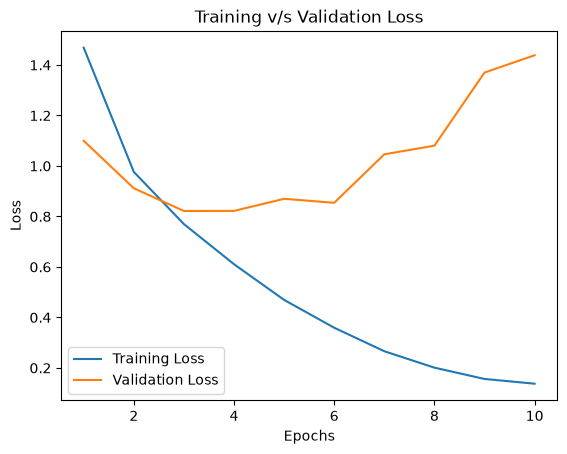

In [10]:
import matplotlib.pyplot as plt

epoch_range = range(1, epochs + 1)

plt.title("Training v/s Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.plot(epoch_range, train_loss_graph, label="Training Loss")
plt.plot(epoch_range, val_loss_graph, label="Validation Loss")

plt.legend()
plt.show()

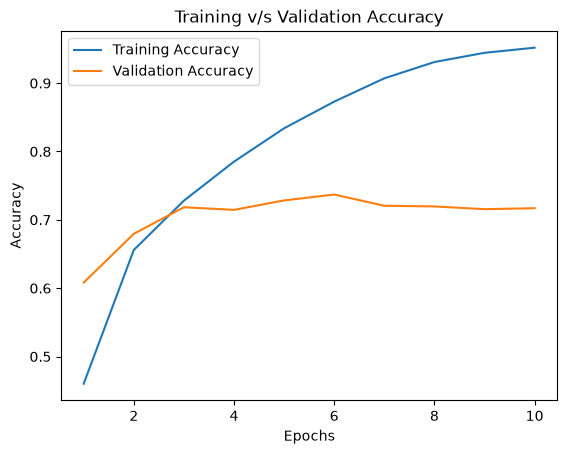

In [11]:
import matplotlib.pyplot as plt

epoch_range = range(1, epochs + 1)

plt.title("Training v/s Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.plot(epoch_range, train_acc_graph, label="Training Accuracy")
plt.plot(epoch_range, val_acc_graph, label="Validation Accuracy")

plt.legend()
plt.show()

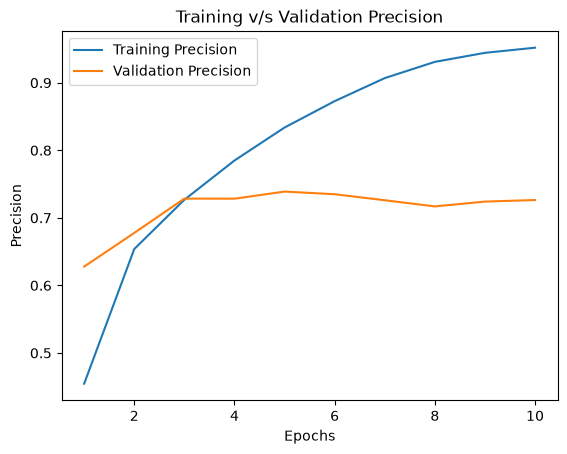

In [12]:
import matplotlib.pyplot as plt

epoch_range = range(1, epochs + 1)

plt.title("Training v/s Validation Precision")
plt.xlabel("Epochs")
plt.ylabel("Precision")

plt.plot(epoch_range, train_prec_graph, label="Training Precision")
plt.plot(epoch_range, val_prec_graph, label="Validation Precision")

plt.legend()
plt.show()

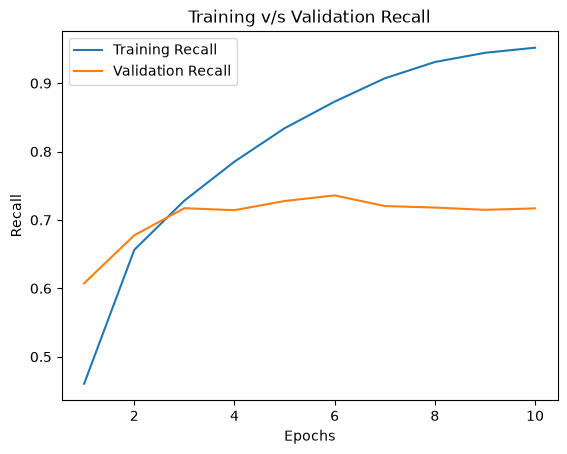

In [13]:
import matplotlib.pyplot as plt

epoch_range = range(1, epochs + 1)

plt.title("Training v/s Validation Recall")
plt.xlabel("Epochs")
plt.ylabel("Recall")

plt.plot(epoch_range, train_rec_graph, label="Training Recall")
plt.plot(epoch_range, val_rec_graph, label="Validation Recall")

plt.legend()
plt.show()